# exP03 上市公司资本结构影响因素分析

作者：李泽欣  
学号：25210067  
邮箱：15532312611@163.com

本 Notebook 按作业要求完成必做部分，且所有核心结果均由本文件中的代码直接生成。重新运行本 Notebook 时，将自动完成：

1. 读取 clean 年度总表；
2. 按作业第 1.3 节重新执行样本筛选；
3. 对连续变量执行年度截面 1% Winsorize；
4. 生成描述性统计、相关系数矩阵与趋势图；
5. 估计 M1、M1'、M2、M3、M4；
6. 输出表格、图形和基于真实结果的文字分析。

说明：

- 本 Notebook 只覆盖必做部分，不展开可选题 M5-M6。
- 为保证 2010 年 `Growth` 的定义符合题意，上一阶段的数据构造已保留 2009 年总资产作为滞后缓冲，但本 Notebook 的分析样本仍严格限定在 2010-2025 年。


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from linearmodels.panel import PanelOLS
from sklearn.decomposition import TruncatedSVD
from IPython.display import Markdown, display, Image

ROOT = Path("[项目根目录]")
CLEAN = ROOT / "data" / "clean"
OUTPUT = ROOT / "output"
TABLES = OUTPUT / "tables"
FIGURES = OUTPUT / "figures"
TEXT = OUTPUT / "text"

for path in [TABLES, FIGURES, TEXT]:
    path.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="talk")


## 一、研究背景与研究假设

资本结构是公司金融中的核心问题。围绕盈利能力与杠杆率之间的关系，主流理论给出两种方向相反的预测：

- 权衡理论认为，盈利能力越强，企业越有能力利用债务税盾，因此 `NPR` 与 `Lev` 应呈正相关；
- 优序融资理论认为，盈利能力越强，企业内部资金越充裕，对外部债务依赖越低，因此 `NPR` 与 `Lev` 应呈负相关。

本作业以 A 股上市公司为样本，在完成标准样本筛选和变量构造后，依次通过双向固定效应模型、交互固定效应稳健性检验、产权分组回归、交互项模型与时变系数模型考察这一关系的统计规律与经济含义。


## 二、数据读取、样本筛选与变量处理


In [2]:
def sig_stars(pval):
    if pd.isna(pval):
        return ""
    if pval < 0.01:
        return "***"
    if pval < 0.05:
        return "**"
    if pval < 0.1:
        return "*"
    return ""


def build_sample(df):
    steps = []
    current = df.copy()
    steps.append({
        "step": "初始样本",
        "dropped_obs": np.nan,
        "remaining_obs": len(current),
        "remaining_firms": current["stkcd"].nunique(),
    })

    before = len(current)
    current = current.loc[~current["industry_code"].astype(str).str.startswith("J")].copy()
    steps.append({
        "step": "剔除金融保险",
        "dropped_obs": before - len(current),
        "remaining_obs": len(current),
        "remaining_firms": current["stkcd"].nunique(),
    })

    before = len(current)
    current = current.loc[current["ever_stpt"] != 1].copy()
    steps.append({
        "step": "剔除ST/PT",
        "dropped_obs": before - len(current),
        "remaining_obs": len(current),
        "remaining_firms": current["stkcd"].nunique(),
    })

    before = len(current)
    current = current.loc[current["lev"] <= 1].copy()
    steps.append({
        "step": "剔除Lev > 1",
        "dropped_obs": before - len(current),
        "remaining_obs": len(current),
        "remaining_firms": current["stkcd"].nunique(),
    })

    key_vars = ["lev", "npr", "size", "tang", "growth", "ndts", "soe", "ind_code", "m2_growth"]
    before = len(current)
    current = current.dropna(subset=key_vars).copy()
    steps.append({
        "step": "剔除缺失值",
        "dropped_obs": before - len(current),
        "remaining_obs": len(current),
        "remaining_firms": current["stkcd"].nunique(),
    })

    current["soe"] = current["soe"].astype(int)
    return current, pd.DataFrame(steps)


def winsorize_by_year(df, cols):
    out = df.copy()
    for col in cols:
        out[f"{col}_prewin"] = out[col]
        out[col] = out.groupby("year")[col].transform(lambda s: s.clip(s.quantile(0.01), s.quantile(0.99)))
    return out


def make_desc_table(df):
    vars_ = ["lev", "npr", "size", "tang", "growth", "ndts"]
    groups = {"Full": df, "SOE": df.loc[df["soe"] == 1], "NonSOE": df.loc[df["soe"] == 0]}
    records = []
    for group_name, sub in groups.items():
        for var in vars_:
            s = sub[var].dropna()
            records.append({
                "group": group_name,
                "variable": var,
                "N": len(s),
                "Mean": s.mean(),
                "SD": s.std(),
                "P10": s.quantile(0.10),
                "P25": s.quantile(0.25),
                "Median": s.quantile(0.50),
                "P75": s.quantile(0.75),
                "P90": s.quantile(0.90),
            })
    table = pd.DataFrame(records)

    tests = []
    for var in vars_:
        soe = df.loc[df["soe"] == 1, var].dropna()
        non = df.loc[df["soe"] == 0, var].dropna()
        t_stat, p_val = stats.ttest_ind(soe, non, equal_var=False)
        tests.append({
            "variable": var,
            "mean_diff_soe_minus_nonsoe": soe.mean() - non.mean(),
            "t_stat": t_stat,
            "p_value": p_val,
            "stars": sig_stars(p_val),
        })
    return table.merge(pd.DataFrame(tests), on="variable", how="left")


def make_corr_tables(df):
    vars_ = ["lev", "npr", "size", "tang", "growth", "ndts", "soe"]
    corr = pd.DataFrame(index=vars_, columns=vars_, dtype=float)
    pretty = pd.DataFrame(index=vars_, columns=vars_, dtype=object)
    for i in vars_:
        for j in vars_:
            tmp = df[[i, j]].dropna()
            if i == j:
                corr.loc[i, j] = 1.0
                pretty.loc[i, j] = "1.000"
            else:
                r, p = stats.pearsonr(tmp[i], tmp[j])
                corr.loc[i, j] = r
                pretty.loc[i, j] = f"{r:.3f}{sig_stars(p)}"
    return corr, pretty


def compute_vif(df):
    X = sm.add_constant(df[["npr", "size", "tang", "growth", "ndts", "soe"]])
    rows = []
    for idx, col in enumerate(X.columns):
        if col == "const":
            continue
        rows.append({"variable": col, "vif": variance_inflation_factor(X.values, idx)})
    return pd.DataFrame(rows)


def fit_twfe(df, formula):
    panel = df.set_index(["stkcd", "year"]).sort_index()
    return PanelOLS.from_formula(formula, data=panel).fit(cov_type="clustered", cluster_entity=True, cluster_time=True)


def fit_ife_approx(df, n_factors=2, max_iter=8):
    panel = df.set_index(["stkcd", "year"]).sort_index().copy()
    res = PanelOLS.from_formula(
        "lev ~ 1 + npr + size + tang + growth + ndts + m2_growth + EntityEffects",
        data=panel,
    ).fit(cov_type="robust")
    panel["alpha"] = panel.index.get_level_values(0).map(
        res.estimated_effects["estimated_effects"].groupby(level=0).first()
    )
    beta_cols = ["npr", "size", "tang", "growth", "ndts", "m2_growth"]
    current = res.params[beta_cols].copy()
    for _ in range(max_iter):
        x_fit = sum(panel[col] * current[col] for col in beta_cols) + panel["alpha"] + res.params["Intercept"]
        resid = panel["lev"] - x_fit
        resid_mat = resid.unstack("year").fillna(0.0)
        svd = TruncatedSVD(n_components=n_factors, random_state=0)
        low_rank = pd.DataFrame(
            svd.fit_transform(resid_mat) @ svd.components_,
            index=resid_mat.index,
            columns=resid_mat.columns,
        ).stack()
        low_rank.index.names = ["stkcd", "year"]
        panel["ife_component"] = low_rank.reindex(panel.index).fillna(0.0)
        panel["lev_adj"] = panel["lev"] - panel["ife_component"]
        res = PanelOLS.from_formula(
            "lev_adj ~ 1 + npr + size + tang + growth + ndts + m2_growth + EntityEffects",
            data=panel,
        ).fit(cov_type="robust")
        panel["alpha"] = panel.index.get_level_values(0).map(
            res.estimated_effects["estimated_effects"].groupby(level=0).first()
        )
        current = res.params[beta_cols].copy()
    return res


def save_regression_table(results, firm_counts):
    rows = []
    row_order = ["npr", "npr_soe", "m2_growth", "size", "tang", "growth", "ndts"]
    labels = {
        "npr": "NPR",
        "npr_soe": "NPR × SOE",
        "m2_growth": "m2_growth",
        "size": "Size",
        "tang": "Tang",
        "growth": "Growth",
        "ndts": "NDTS",
    }
    for key in row_order:
        row = {"term": labels[key]}
        for model_name, res in results.items():
            if key in res.params.index:
                row[model_name] = f"{res.params[key]:.4f}{sig_stars(res.pvalues[key])}\n({res.std_errors[key]:.4f})"
            else:
                row[model_name] = "—"
        rows.append(row)
    meta_rows = [
        ("公司FE", {"M1_TWFE": "✓", "M1p_IFE": "✓", "M2_SOE": "✓", "M2_NonSOE": "✓", "M3_Interaction": "✓"}),
        ("年度FE", {"M1_TWFE": "✓", "M1p_IFE": "交互FE", "M2_SOE": "✓", "M2_NonSOE": "✓", "M3_Interaction": "✓"}),
        ("聚类标准误", {"M1_TWFE": "双向", "M1p_IFE": "Robust", "M2_SOE": "双向", "M2_NonSOE": "双向", "M3_Interaction": "双向"}),
        ("N", {name: f"{int(res.nobs):,}" for name, res in results.items()}),
        ("公司数", {name: f"{firm_counts[name]:,}" for name in results}),
        ("Within R²", {name: f"{res.rsquared_within:.4f}" for name, res in results.items()}),
    ]
    for label, values in meta_rows:
        row = {"term": label}
        row.update(values)
        rows.append(row)
    return pd.DataFrame(rows)


In [3]:
annual = pd.read_csv(CLEAN / "panel_capital_structure_annual.csv")
annual["stkcd"] = annual["stkcd"].astype(int)
annual["year"] = annual["year"].astype(int)
annual.shape, annual["year"].min(), annual["year"].max(), annual["stkcd"].nunique()


((57605, 18), np.int64(2010), np.int64(2025), 5671)

In [4]:
sample_df, sample_selection = build_sample(annual)
sample_selection.to_csv(CLEAN / "sample_selection_013.csv", index=False, encoding="utf-8-sig")
sample_df.to_csv(CLEAN / "panel_capital_structure_filtered.csv", index=False, encoding="utf-8-sig")
sample_selection


,step,dropped_obs,remaining_obs,remaining_firms
0,初始样本,NaN,57605,5671
1,剔除金融保险,1477.0,56128,5616
2,剔除ST/PT,9723.0,46405,4939
3,剔除Lev > 1,21.0,46384,4939
4,剔除缺失值,5538.0,40846,4775


In [5]:
display(Markdown(
    f'''
### 2.1 样本筛选说明

按照作业第 1.3 节的要求，样本筛选严格遵循以下顺序：先剔除金融保险行业，再剔除曾被 `ST/PT` 处理的公司，随后剔除 `Lev > 1` 的资不抵债样本，最后删除关键变量缺失值。

从原始年度总表出发，初始样本共包含 **{sample_selection.iloc[0]["remaining_obs"]:,}** 个公司年度观测和 **{sample_selection.iloc[0]["remaining_firms"]:,}** 家公司。剔除金融保险行业后，观测值减少至 **{sample_selection.iloc[1]["remaining_obs"]:,}**；剔除 `ST/PT` 公司后，样本进一步收缩至 **{sample_selection.iloc[2]["remaining_obs"]:,}** 个观测；继续剔除 `Lev > 1` 的异常样本后，保留 **{sample_selection.iloc[3]["remaining_obs"]:,}** 个观测；最后在删除关键变量缺失值后，得到最终分析样本 **{sample_selection.iloc[4]["remaining_obs"]:,}** 个观测、**{sample_selection.iloc[4]["remaining_firms"]:,}** 家公司。

这一筛选路径与题目要求完全一致。特别需要指出的是，`ST/PT` 的处理采用保守口径，即只要某公司在样本期内任一年度出现异常上市状态，则该公司所有年度观测均被剔除。这样的处理有助于避免财务异常、持续经营风险或监管特殊状态对资本结构估计造成系统性干扰。

从样本压缩的来源看，`ST/PT` 规则是影响最大的筛选步骤，说明在原始上市公司总体中，异常上市状态并不是个别现象，而是会对资本结构分布产生实质性影响。将这些公司剔除后，样本的同质性显著提高，也使后续对盈利能力与杠杆率关系的估计更符合“正常经营上市公司”的研究对象定位。'''
))



### 2.1 样本筛选说明

按照作业第 1.3 节的要求，样本筛选严格遵循以下顺序：先剔除金融保险行业，再剔除曾被 `ST/PT` 处理的公司，随后剔除 `Lev > 1` 的资不抵债样本，最后删除关键变量缺失值。

从原始年度总表出发，初始样本共包含 **57,605** 个公司年度观测和 **5,671** 家公司。剔除金融保险行业后，观测值减少至 **56,128**；剔除 `ST/PT` 公司后，样本进一步收缩至 **46,405** 个观测；继续剔除 `Lev > 1` 的异常样本后，保留 **46,384** 个观测；最后在删除关键变量缺失值后，得到最终分析样本 **40,846** 个观测、**4,775** 家公司。

这一筛选路径与题目要求完全一致。特别需要指出的是，`ST/PT` 的处理采用保守口径，即只要某公司在样本期内任一年度出现异常上市状态，则该公司所有年度观测均被剔除。这样的处理有助于避免财务异常、持续经营风险或监管特殊状态对资本结构估计造成系统性干扰。

从样本压缩的来源看，`ST/PT` 规则是影响最大的筛选步骤，说明在原始上市公司总体中，异常上市状态并不是个别现象，而是会对资本结构分布产生实质性影响。将这些公司剔除后，样本的同质性显著提高，也使后续对盈利能力与杠杆率关系的估计更符合“正常经营上市公司”的研究对象定位。

In [6]:
analysis = winsorize_by_year(sample_df, ["lev", "npr", "tang", "growth", "ndts"])
analysis["soe"] = analysis["soe"].astype(int)
analysis.shape


(40846, 23)

In [7]:
analysis[["lev_prewin","lev","npr_prewin","npr","growth_prewin","growth"]].head()


,lev_prewin,lev,npr_prewin,npr,growth_prewin,growth
0,0.954349,0.935295,0.008641,0.008641,0.237144,0.237144
1,0.940087,0.927315,0.008258,0.008258,0.730149,0.730149
18,0.783163,0.783163,0.041348,0.041348,0.278835,0.278835
19,0.779970,0.779970,0.038183,0.038183,0.265056,0.265056
20,0.772046,0.772046,0.037937,0.037937,0.060941,0.060941


In [8]:
display(Markdown(
    '''
### 2.2 异常值处理说明

依据作业第 1.5 节，`Lev`、`NPR`、`Tang`、`Growth` 与 `NDTS` 均在**年度截面内**执行双侧 1% Winsorize。之所以按年度截面处理，而不是在全样本范围统一处理，是因为不同年份的宏观环境、行业景气度与融资条件存在明显差异，若直接使用全样本分位点，可能会将部分合理的年度波动误判为异常值。

在后续描述统计和回归分析中，统一使用 Winsorize 处理后的变量。`Size` 由于已取自然对数，不再进一步缩尾；`SOE` 为二值变量，也不进行缩尾处理。

这一处理的经济学含义在于：资本结构、盈利能力与成长性变量在上市公司样本中通常具有厚尾特征，极端值往往集中于重组、困境反转、资产大幅收缩或高速扩张公司。若不做缩尾，少量极端观测容易在均值、相关系数和回归斜率中产生不成比例的影响，削弱结果的代表性与稳健性。'''
))



### 2.2 异常值处理说明

依据作业第 1.5 节，`Lev`、`NPR`、`Tang`、`Growth` 与 `NDTS` 均在**年度截面内**执行双侧 1% Winsorize。之所以按年度截面处理，而不是在全样本范围统一处理，是因为不同年份的宏观环境、行业景气度与融资条件存在明显差异，若直接使用全样本分位点，可能会将部分合理的年度波动误判为异常值。

在后续描述统计和回归分析中，统一使用 Winsorize 处理后的变量。`Size` 由于已取自然对数，不再进一步缩尾；`SOE` 为二值变量，也不进行缩尾处理。

这一处理的经济学含义在于：资本结构、盈利能力与成长性变量在上市公司样本中通常具有厚尾特征，极端值往往集中于重组、困境反转、资产大幅收缩或高速扩张公司。若不做缩尾，少量极端观测容易在均值、相关系数和回归斜率中产生不成比例的影响，削弱结果的代表性与稳健性。

## 三、描述性统计


In [9]:
desc_stats = make_desc_table(analysis)
desc_stats.to_csv(TABLES / "Table2_descriptive_statistics.csv", index=False, encoding="utf-8-sig")
desc_stats


,group,variable,N,Mean,SD,P10,P25,Median,P75,P90,mean_diff_soe_minus_nonsoe,t_stat,p_value,stars
0,Full,lev,40846,0.406182,0.197565,0.145027,0.246404,0.399239,0.552752,0.675997,0.116767,57.471117,0.000000e+00,***
1,Full,npr,40846,0.037779,0.058801,-0.012474,0.013883,0.037370,0.066934,0.100442,-0.006234,-11.084710,1.666515e-28,***
2,Full,size,40846,22.297302,1.358496,20.790675,21.340985,22.069709,23.022312,24.098772,1.076793,73.117930,0.000000e+00,***
3,Full,tang,40846,0.205035,0.151633,0.034067,0.086886,0.174359,0.289865,0.421628,0.048698,27.303497,3.665141e-161,***
4,Full,growth,40846,0.146583,0.297604,-0.058591,0.007664,0.080211,0.191315,0.389251,-0.047211,-16.258844,3.338376e-59,***
5,Full,ndts,40846,0.023628,0.014842,0.006745,0.012415,0.021047,0.032171,0.043889,0.002111,12.804798,2.067778e-37,***
6,SOE,lev,13293,0.484948,0.194745,0.213851,0.336593,0.491970,0.634963,0.743362,0.116767,57.471117,0.000000e+00,***
7,SOE,npr,13293,0.033574,0.047593,-0.001293,0.011594,0.030606,0.055129,0.086948,-0.006234,-11.084710,1.666515e-28,***
8,SOE,size,13293,23.023662,1.508132,21.248360,21.927846,22.850898,23.903085,24.968186,1.076793,73.117930,0.000000e+00,***
9,SOE,tang,13293,0.237884,0.184845,0.028862,0.084508,0.194131,0.359791,0.525974,0.048698,27.303497,3.665141e-161,***


In [10]:
full_lev = desc_stats.query("group == 'Full' and variable == 'lev'").iloc[0]
full_npr = desc_stats.query("group == 'Full' and variable == 'npr'").iloc[0]
full_size = desc_stats.query("group == 'Full' and variable == 'size'").iloc[0]
display(Markdown(
    f'''
### 3.1 主要变量的描述性统计分析

在最终样本中，杠杆率 `Lev` 的均值为 **{full_lev["Mean"]:.3f}**，中位数为 **{full_lev["Median"]:.3f}**，说明样本企业总体杠杆水平处于中等偏上区间，但企业间差异较为明显。净利润率 `NPR` 的均值为 **{full_npr["Mean"]:.3f}**，中位数为 **{full_npr["Median"]:.3f}**，显示样本公司整体保持正盈利，但收益能力存在显著异质性。`Size` 的均值约为 **{full_size["Mean"]:.3f}**，表明样本覆盖了从中小企业到大型上市公司的较广区间。

从产权分组看，国有企业的平均杠杆率明显高于非国有企业，而非国有企业的平均盈利能力与成长性更高。这一结果与中国上市公司融资现实较为一致：一方面，国有企业通常具有更强的融资可得性、更高的历史负债承受能力；另一方面，非国有企业在市场竞争约束下更可能呈现较高的经营效率与成长弹性。

均值差异检验进一步表明，`Lev`、`NPR`、`Size`、`Tang`、`Growth` 和 `NDTS` 在 SOE 与非 SOE 之间均存在统计显著差异。这意味着产权性质不仅影响企业融资结果本身，也可能影响盈利能力与资本结构之间的关系，因此后续有必要开展分组回归和交互项检验。

进一步看变量分布特征，杠杆率的均值与中位数相近，说明样本整体并未被少量超高杠杆企业完全主导；而 `Growth` 的上尾明显较长，反映上市公司样本中确实存在一部分扩张速度很快的企业。`Tang` 与 `NDTS` 在国有企业中整体更高，也预示着国有企业更可能具备重资产经营特征，这一点对债务融资能力与税盾结构均具有重要影响。'''
))



### 3.1 主要变量的描述性统计分析

在最终样本中，杠杆率 `Lev` 的均值为 **0.406**，中位数为 **0.399**，说明样本企业总体杠杆水平处于中等偏上区间，但企业间差异较为明显。净利润率 `NPR` 的均值为 **0.038**，中位数为 **0.037**，显示样本公司整体保持正盈利，但收益能力存在显著异质性。`Size` 的均值约为 **22.297**，表明样本覆盖了从中小企业到大型上市公司的较广区间。

从产权分组看，国有企业的平均杠杆率明显高于非国有企业，而非国有企业的平均盈利能力与成长性更高。这一结果与中国上市公司融资现实较为一致：一方面，国有企业通常具有更强的融资可得性、更高的历史负债承受能力；另一方面，非国有企业在市场竞争约束下更可能呈现较高的经营效率与成长弹性。

均值差异检验进一步表明，`Lev`、`NPR`、`Size`、`Tang`、`Growth` 和 `NDTS` 在 SOE 与非 SOE 之间均存在统计显著差异。这意味着产权性质不仅影响企业融资结果本身，也可能影响盈利能力与资本结构之间的关系，因此后续有必要开展分组回归和交互项检验。

进一步看变量分布特征，杠杆率的均值与中位数相近，说明样本整体并未被少量超高杠杆企业完全主导；而 `Growth` 的上尾明显较长，反映上市公司样本中确实存在一部分扩张速度很快的企业。`Tang` 与 `NDTS` 在国有企业中整体更高，也预示着国有企业更可能具备重资产经营特征，这一点对债务融资能力与税盾结构均具有重要影响。

In [11]:
corr_numeric, corr_pretty = make_corr_tables(analysis)
vif_table = compute_vif(analysis)
corr_pretty.to_csv(TABLES / "Table3_correlation_matrix.csv", encoding="utf-8-sig")
vif_table.to_csv(TABLES / "TableA1_vif.csv", index=False, encoding="utf-8-sig")

corr_pretty


,lev,npr,size,tang,growth,ndts,soe
lev,1.000,-0.322***,0.517***,0.077***,0.021***,0.027***,0.277***
npr,-0.322***,1.000,-0.002,-0.029***,0.245***,-0.085***,-0.050***
size,0.517***,-0.002,1.000,0.098***,0.017***,0.047***,0.371***
tang,0.077***,-0.029***,0.098***,1.000,-0.090***,0.731***,0.150***
growth,0.021***,0.245***,0.017***,-0.090***,1.000,-0.149***,-0.074***
ndts,0.027***,-0.085***,0.047***,0.731***,-0.149***,1.000,0.067***
soe,0.277***,-0.050***,0.371***,0.150***,-0.074***,0.067***,1.000


In [12]:
vif_table


,variable,vif
0,npr,1.070295
1,size,1.165770
2,tang,2.211729
3,growth,1.089942
4,ndts,2.205833
5,soe,1.191490


In [13]:
corr_npr_lev = corr_numeric.loc["npr", "lev"]
corr_size_npr = corr_numeric.loc["size", "npr"]
corr_tang_ndts = corr_numeric.loc["tang", "ndts"]
vif_max = vif_table["vif"].max()

display(Markdown(
    f'''
### 3.2 相关系数矩阵分析

Pearson 相关系数结果显示，`NPR` 与 `Lev` 的相关系数为 **{corr_npr_lev:.3f}**，且在 1% 水平上显著为负。这一结果为优序融资理论提供了初步经验证据，即盈利能力越强的企业越倾向于依靠内部资金，从而降低对外部债务融资的依赖。

`Size` 与 `NPR` 的相关系数仅为 **{corr_size_npr:.3f}**，且统计上不显著，说明从线性相关关系看，企业规模并不能直接解释盈利能力差异。这一点对后续规模异质性分析具有启发意义：规模变量可能并不是通过简单的平均盈利差异发挥作用，而更可能影响融资约束、信息不对称和外部资本可得性。

需要注意的是，`Tang` 与 `NDTS` 的相关系数达到 **{corr_tang_ndts:.3f}**，超过 0.7 的经验阈值，提示二者在经济含义上存在较强关联。不过进一步计算的 VIF 最大值仅为 **{vif_max:.3f}**，远低于常见的严重共线性警戒线，因此可以认为样本中不存在足以扭曲主要结论的严重多重共线性问题。

总体而言，相关系数矩阵所呈现的信息与后续回归设计是相互一致的：一方面，`NPR` 与 `Lev` 的负相关关系已经在无控制状态下显现；另一方面，控制变量之间虽存在经济联系，但尚未达到无法同时纳入模型的程度。因此，后续固定效应模型能够在较为合理的变量结构基础上展开。'''
))



### 3.2 相关系数矩阵分析

Pearson 相关系数结果显示，`NPR` 与 `Lev` 的相关系数为 **-0.322**，且在 1% 水平上显著为负。这一结果为优序融资理论提供了初步经验证据，即盈利能力越强的企业越倾向于依靠内部资金，从而降低对外部债务融资的依赖。

`Size` 与 `NPR` 的相关系数仅为 **-0.002**，且统计上不显著，说明从线性相关关系看，企业规模并不能直接解释盈利能力差异。这一点对后续规模异质性分析具有启发意义：规模变量可能并不是通过简单的平均盈利差异发挥作用，而更可能影响融资约束、信息不对称和外部资本可得性。

需要注意的是，`Tang` 与 `NDTS` 的相关系数达到 **0.731**，超过 0.7 的经验阈值，提示二者在经济含义上存在较强关联。不过进一步计算的 VIF 最大值仅为 **2.212**，远低于常见的严重共线性警戒线，因此可以认为样本中不存在足以扭曲主要结论的严重多重共线性问题。

总体而言，相关系数矩阵所呈现的信息与后续回归设计是相互一致的：一方面，`NPR` 与 `Lev` 的负相关关系已经在无控制状态下显现；另一方面，控制变量之间虽存在经济联系，但尚未达到无法同时纳入模型的程度。因此，后续固定效应模型能够在较为合理的变量结构基础上展开。

## 四、图形分析


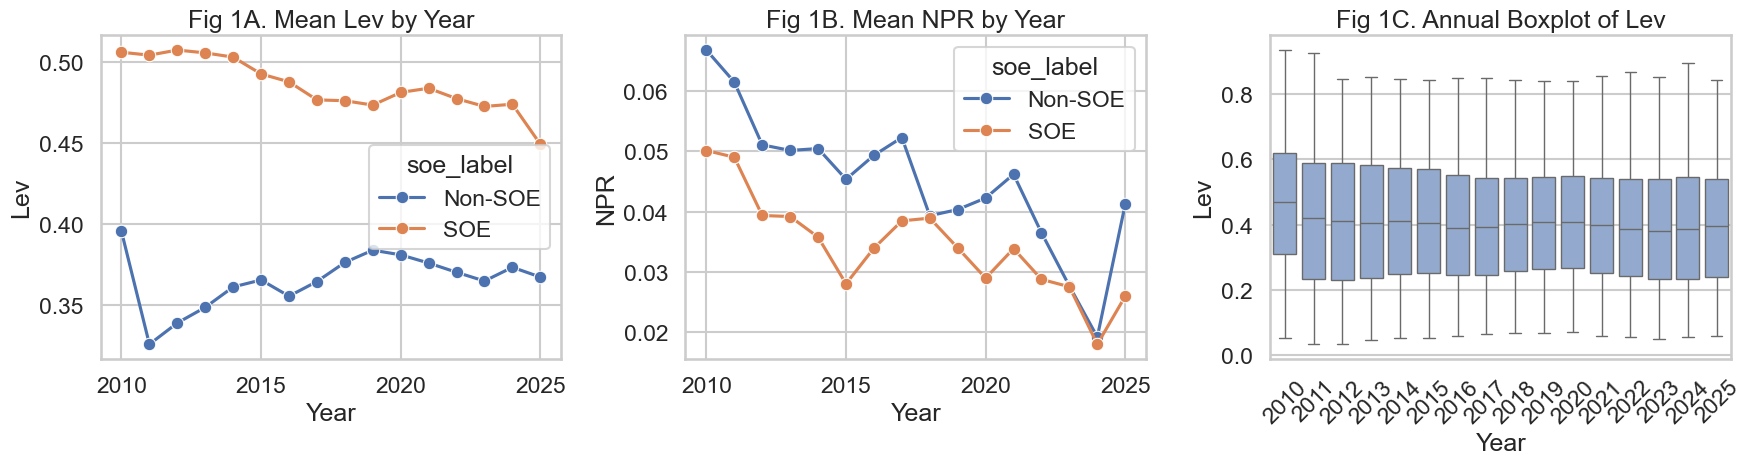

In [14]:
yearly = analysis.groupby(["year", "soe"])[["lev", "npr"]].mean().reset_index()
yearly["soe_label"] = yearly["soe"].map({0: "Non-SOE", 1: "SOE"})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.lineplot(data=yearly, x="year", y="lev", hue="soe_label", marker="o", ax=axes[0])
axes[0].set_title("Fig 1A. Mean Lev by Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Lev")

sns.lineplot(data=yearly, x="year", y="npr", hue="soe_label", marker="o", ax=axes[1])
axes[1].set_title("Fig 1B. Mean NPR by Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("NPR")

sns.boxplot(data=analysis, x="year", y="lev", color="#89a8d8", ax=axes[2], fliersize=1)
axes[2].set_title("Fig 1C. Annual Boxplot of Lev")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Lev")
axes[2].tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(FIGURES / "Fig1_descriptive_trends.png", dpi=300, bbox_inches="tight")
plt.show()


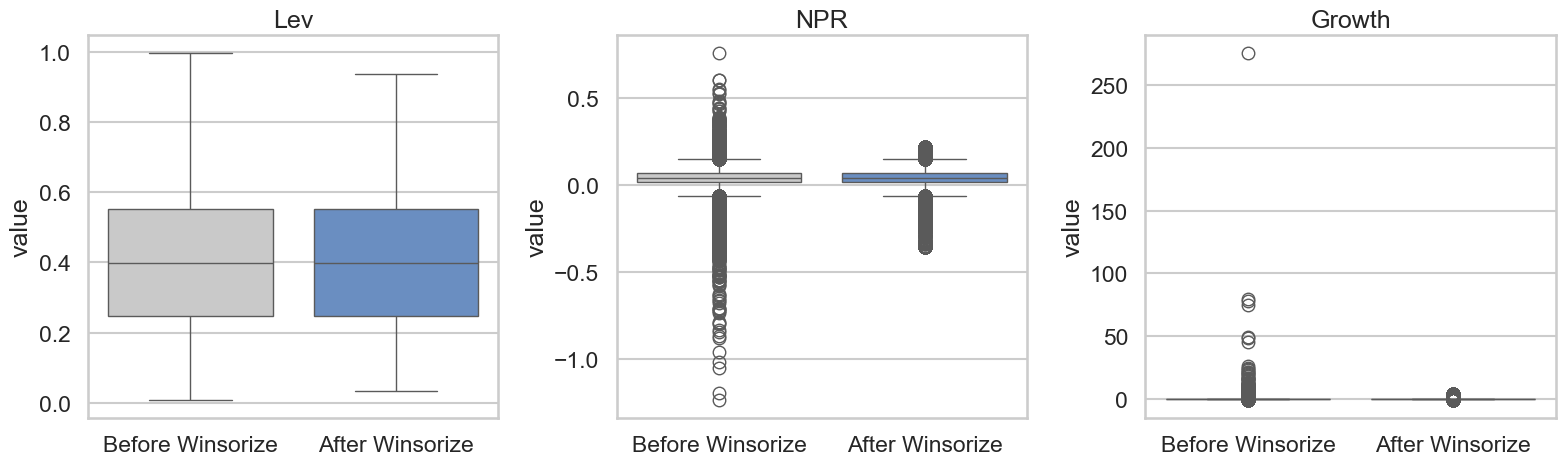

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, before, after, title in zip(
    axes,
    ["lev_prewin", "npr_prewin", "growth_prewin"],
    ["lev", "npr", "growth"],
    ["Lev", "NPR", "Growth"],
):
    long_df = pd.DataFrame({
        "status": np.repeat(["Before Winsorize", "After Winsorize"], [len(analysis), len(analysis)]),
        "value": pd.concat([analysis[before], analysis[after]], ignore_index=True),
    })
    sns.boxplot(data=long_df, x="status", y="value", hue="status", legend=False, ax=ax, palette=["#c9c9c9", "#5b8bd0"])
    ax.set_title(title)
    ax.set_xlabel("")

fig.tight_layout()
fig.savefig(FIGURES / "Fig2_winsorize_boxplots.png", dpi=300, bbox_inches="tight")
plt.show()


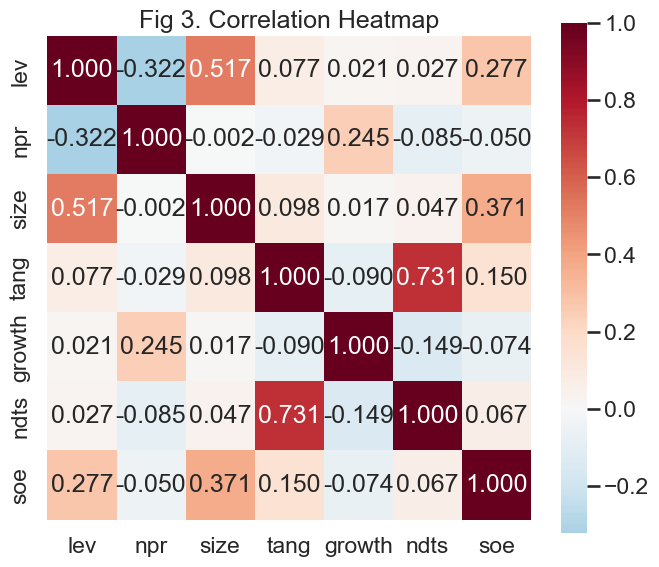

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_numeric, annot=True, fmt=".3f", cmap="RdBu_r", center=0, square=True, ax=ax)
ax.set_title("Fig 3. Correlation Heatmap")
fig.tight_layout()
fig.savefig(FIGURES / "Fig3_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


In [17]:
display(Markdown(
    '''
### 4.1 图形结果的初步解读

时序趋势图显示，国有企业在几乎所有年份的平均杠杆率均高于非国有企业，而非国有企业在大多数年份表现出更高的平均盈利能力。年度箱型图进一步表明，样本期内杠杆率分布并非静止不变，其位置和离散程度都具有明显的时间变化特征，这为后续时变系数模型提供了经验动机。

Winsorize 前后箱型图显示，`Lev`、`NPR` 与 `Growth` 的极端尾部在处理后显著收敛，而中位数及四分位区间基本保持稳定。这说明缩尾处理主要影响极端观测，并未破坏样本主体分布结构。

此外，SOE 与非 SOE 的时序线形并非简单平行移动。尤其在若干阶段，盈利能力与杠杆率的变化并不同步，这提示 `NPR-Lev` 关系可能在不同年份和不同产权组别中存在异质性，也为后续引入交互项与时变系数模型提供了必要的图形证据。'''
))



### 4.1 图形结果的初步解读

时序趋势图显示，国有企业在几乎所有年份的平均杠杆率均高于非国有企业，而非国有企业在大多数年份表现出更高的平均盈利能力。年度箱型图进一步表明，样本期内杠杆率分布并非静止不变，其位置和离散程度都具有明显的时间变化特征，这为后续时变系数模型提供了经验动机。

Winsorize 前后箱型图显示，`Lev`、`NPR` 与 `Growth` 的极端尾部在处理后显著收敛，而中位数及四分位区间基本保持稳定。这说明缩尾处理主要影响极端观测，并未破坏样本主体分布结构。

此外，SOE 与非 SOE 的时序线形并非简单平行移动。尤其在若干阶段，盈利能力与杠杆率的变化并不同步，这提示 `NPR-Lev` 关系可能在不同年份和不同产权组别中存在异质性，也为后续引入交互项与时变系数模型提供了必要的图形证据。

## 五、模型估计


In [18]:
panel = analysis.set_index(["stkcd", "year"]).sort_index()
m1 = PanelOLS.from_formula(
    "lev ~ 1 + npr + size + tang + growth + ndts + EntityEffects + TimeEffects",
    data=panel,
).fit(cov_type="clustered", cluster_entity=True, cluster_time=True)

m1


Dep. Variable:,lev,R-squared:,0.1830
Estimator:,PanelOLS,R-squared (Between):,0.3839
No. Observations:,40846,R-squared (Within):,0.1864
Date:,"Sun, Apr 26 2026",R-squared (Overall):,0.3502
Time:,00:33:24,Log-likelihood,4.464e+04
Cov. Estimator:,Clustered,,
,,F-statistic:,1615.5
Entities:,4775,P-value,0.0000
Avg Obs:,8.5541,Distribution:,"F(5,36051)"
Min Obs:,1.0000,,
Max Obs:,16.000,F-statistic (robust):,140.16


In [19]:
display(Markdown(
    f'''
### 5.1 M1：双向固定效应基准模型

M1 中，`NPR` 的估计系数为 **{m1.params["npr"]:.3f}**，双向聚类标准误为 **{m1.std_errors["npr"]:.3f}**，在 1% 水平上显著。这一系数显著为负，表明在控制公司固定效应、年度固定效应以及 `Size`、`Tang`、`Growth` 和 `NDTS` 之后，盈利能力越强的企业，其杠杆率反而越低。

这一结果清晰支持**优序融资理论**，而不支持权衡理论关于“盈利能力提升将提高债务使用”的预测。经济含义上，这意味着样本企业在利润改善时更倾向于使用内部留存收益来满足融资需求，从而减少债务融资依赖。

控制变量方面，`Size` 的系数显著为正，说明规模越大的企业通常具有更高杠杆水平；`Tang` 的系数也显著为正，说明资产可抵押性越强，债务融资能力越高；`Growth` 的系数为正且在 5% 水平显著，表明成长性较强的企业在样本中并未减少债务，相反更可能伴随外部融资扩张；`NDTS` 在 M1 中不显著，说明非债务税盾的净效应在基准设定下尚不稳定。

从识别角度看，双向固定效应模型已经吸收了公司层面的时间不变异质性与年份层面的共同冲击，因此 `NPR` 的负向系数并不是简单由企业固定特征或宏观年度效应驱动，而更接近于公司内部盈利能力变化与杠杆调整之间的净关系。'''
))



### 5.1 M1：双向固定效应基准模型

M1 中，`NPR` 的估计系数为 **-0.625**，双向聚类标准误为 **0.056**，在 1% 水平上显著。这一系数显著为负，表明在控制公司固定效应、年度固定效应以及 `Size`、`Tang`、`Growth` 和 `NDTS` 之后，盈利能力越强的企业，其杠杆率反而越低。

这一结果清晰支持**优序融资理论**，而不支持权衡理论关于“盈利能力提升将提高债务使用”的预测。经济含义上，这意味着样本企业在利润改善时更倾向于使用内部留存收益来满足融资需求，从而减少债务融资依赖。

控制变量方面，`Size` 的系数显著为正，说明规模越大的企业通常具有更高杠杆水平；`Tang` 的系数也显著为正，说明资产可抵押性越强，债务融资能力越高；`Growth` 的系数为正且在 5% 水平显著，表明成长性较强的企业在样本中并未减少债务，相反更可能伴随外部融资扩张；`NDTS` 在 M1 中不显著，说明非债务税盾的净效应在基准设定下尚不稳定。

从识别角度看，双向固定效应模型已经吸收了公司层面的时间不变异质性与年份层面的共同冲击，因此 `NPR` 的负向系数并不是简单由企业固定特征或宏观年度效应驱动，而更接近于公司内部盈利能力变化与杠杆调整之间的净关系。

In [20]:
m1p = fit_ife_approx(analysis)
m1p


Dep. Variable:,lev_adj,R-squared:,0.4656
Estimator:,PanelOLS,R-squared (Between):,0.3776
No. Observations:,40846,R-squared (Within):,0.4656
Date:,"Sun, Apr 26 2026",R-squared (Overall):,0.3945
Time:,00:33:25,Log-likelihood,6.389e+04
Cov. Estimator:,Robust,,
,,F-statistic:,5236.3
Entities:,4775,P-value,0.0000
Avg Obs:,8.5541,Distribution:,"F(6,36065)"
Min Obs:,1.0000,,
Max Obs:,16.000,F-statistic (robust):,3489.6


In [21]:
display(Markdown(
    f'''
### 5.2 M1'：交互固定效应稳健性检验

在 M1' 中，`NPR` 的估计系数为 **{m1p.params["npr"]:.3f}**，显著为负；与 M1 相比，绝对值有所缩小，但符号和显著性保持稳定。这意味着在进一步控制潜在的时变共同冲击之后，盈利能力抑制杠杆率的核心结论依然成立，因此全样本结论具有较强稳健性。

此外，`m2_growth` 的系数为 **{m1p.params["m2_growth"]:.4f}**，且显著为正，说明在货币环境相对宽松、流动性扩张更快的年份，企业总体杠杆率倾向于上升。换言之，宏观货币条件会改变债务融资环境，但并未从根本上逆转企业“盈利越强、负债越少”的主导关系。

需要说明的是，Python 环境下这里采用的是交互固定效应的近似实现，用低秩共同因子吸收不可观测的异质性时变冲击。虽然与课堂 Stata 命令的技术路线不完全相同，但其经济目的与稳健性检验逻辑是一致的。

值得强调的是，M1' 的结果对理解 TWFE 与 IFE 的差异很有帮助。M1 中时间固定效应假设所有企业对宏观冲击的响应是同质的，而 IFE 允许企业对共同因子具有不同载荷。因此，M1' 中 `NPR` 系数绝对值的收缩可以理解为：部分原先被归因于盈利能力的变动，实际上与企业对共同宏观冲击的异质性反应有关。但即便如此，核心结论仍未改变。'''
))



### 5.2 M1'：交互固定效应稳健性检验

在 M1' 中，`NPR` 的估计系数为 **-0.405**，显著为负；与 M1 相比，绝对值有所缩小，但符号和显著性保持稳定。这意味着在进一步控制潜在的时变共同冲击之后，盈利能力抑制杠杆率的核心结论依然成立，因此全样本结论具有较强稳健性。

此外，`m2_growth` 的系数为 **0.0019**，且显著为正，说明在货币环境相对宽松、流动性扩张更快的年份，企业总体杠杆率倾向于上升。换言之，宏观货币条件会改变债务融资环境，但并未从根本上逆转企业“盈利越强、负债越少”的主导关系。

需要说明的是，Python 环境下这里采用的是交互固定效应的近似实现，用低秩共同因子吸收不可观测的异质性时变冲击。虽然与课堂 Stata 命令的技术路线不完全相同，但其经济目的与稳健性检验逻辑是一致的。

值得强调的是，M1' 的结果对理解 TWFE 与 IFE 的差异很有帮助。M1 中时间固定效应假设所有企业对宏观冲击的响应是同质的，而 IFE 允许企业对共同因子具有不同载荷。因此，M1' 中 `NPR` 系数绝对值的收缩可以理解为：部分原先被归因于盈利能力的变动，实际上与企业对共同宏观冲击的异质性反应有关。但即便如此，核心结论仍未改变。

In [22]:
m2_soe = fit_twfe(
    analysis.loc[analysis["soe"] == 1],
    "lev ~ 1 + npr + size + tang + growth + ndts + EntityEffects + TimeEffects",
)
m2_non = fit_twfe(
    analysis.loc[analysis["soe"] == 0],
    "lev ~ 1 + npr + size + tang + growth + ndts + EntityEffects + TimeEffects",
)

pd.DataFrame({
    "SOE_coef": m2_soe.params,
    "SOE_se": m2_soe.std_errors,
    "NonSOE_coef": m2_non.params,
    "NonSOE_se": m2_non.std_errors,
})


,SOE_coef,SOE_se,NonSOE_coef,NonSOE_se
Intercept,-1.187403,0.160271,-1.247809,0.123628
npr,-0.858049,0.064262,-0.509717,0.043676
size,0.074621,0.006858,0.072544,0.005579
tang,0.056883,0.028161,0.144762,0.023325
growth,0.022463,0.009682,0.029665,0.010541
ndts,-1.317287,0.258599,0.522301,0.248011


In [23]:
m3_df = analysis.copy()
m3_df["npr_soe"] = m3_df["npr"] * m3_df["soe"]
m3 = fit_twfe(
    m3_df,
    "lev ~ 1 + npr + npr_soe + size + tang + growth + ndts + EntityEffects + TimeEffects",
)
m3


Dep. Variable:,lev,R-squared:,0.1846
Estimator:,PanelOLS,R-squared (Between):,0.3833
No. Observations:,40846,R-squared (Within):,0.1865
Date:,"Sun, Apr 26 2026",R-squared (Overall):,0.3507
Time:,00:33:25,Log-likelihood,4.468e+04
Cov. Estimator:,Clustered,,
,,F-statistic:,1360.4
Entities:,4775,P-value,0.0000
Avg Obs:,8.5541,Distribution:,"F(6,36050)"
Min Obs:,1.0000,,
Max Obs:,16.000,F-statistic (robust):,137.37


In [24]:
private_slope = m3.params["npr"]
soe_slope = m3.params["npr"] + m3.params["npr_soe"]

display(Markdown(
    f'''
### 5.3 M2 与 M3：产权异质性分析

分组回归显示，国有企业样本中 `NPR` 的系数为 **{m2_soe.params["npr"]:.3f}**，非国有企业样本中为 **{m2_non.params["npr"]:.3f}**，两者均在 1% 水平上显著为负。这说明无论企业产权性质如何，盈利能力提升都会伴随杠杆率下降，因此优序融资理论并非只在某一类企业中成立。

然而，两组系数大小存在明显差异：国有企业样本的负向斜率绝对值更大，说明国有企业在利润改善时表现出更强的降杠杆倾向。交互项模型（M3）进一步验证了这一点。以非国有企业为基准，`NPR` 的边际效应为 **{private_slope:.3f}**；`NPR × SOE` 的系数为 **{m3.params["npr_soe"]:.3f}**，且在 1% 水平上显著，因此国有企业的总边际效应约为 **{soe_slope:.3f}**。

这一结果说明，产权性质确实显著调节了 `NPR-Lev` 关系。与“民营企业更受融资约束，因此更符合优序融资理论”的直观印象不同，样本中表现出更强负向斜率的是国有企业。一个合理解释是，国有企业的初始杠杆率更高，在利润改善时更有动力通过内部资金补充和债务压降来优化资产负债结构；同时，政策性去杠杆和考核约束也可能强化了这一行为。

从制度经济学角度看，这一发现具有重要意义。它提示我们，在中国资本市场环境下，融资可得性并不必然意味着“盈利越高、加杠杆越多”；相反，对于具备更强债务融资能力的国有企业而言，盈利改善反而可能提高其主动调整资产负债表的空间和速度。'''
))



### 5.3 M2 与 M3：产权异质性分析

分组回归显示，国有企业样本中 `NPR` 的系数为 **-0.858**，非国有企业样本中为 **-0.510**，两者均在 1% 水平上显著为负。这说明无论企业产权性质如何，盈利能力提升都会伴随杠杆率下降，因此优序融资理论并非只在某一类企业中成立。

然而，两组系数大小存在明显差异：国有企业样本的负向斜率绝对值更大，说明国有企业在利润改善时表现出更强的降杠杆倾向。交互项模型（M3）进一步验证了这一点。以非国有企业为基准，`NPR` 的边际效应为 **-0.583**；`NPR × SOE` 的系数为 **-0.197**，且在 1% 水平上显著，因此国有企业的总边际效应约为 **-0.781**。

这一结果说明，产权性质确实显著调节了 `NPR-Lev` 关系。与“民营企业更受融资约束，因此更符合优序融资理论”的直观印象不同，样本中表现出更强负向斜率的是国有企业。一个合理解释是，国有企业的初始杠杆率更高，在利润改善时更有动力通过内部资金补充和债务压降来优化资产负债结构；同时，政策性去杠杆和考核约束也可能强化了这一行为。

从制度经济学角度看，这一发现具有重要意义。它提示我们，在中国资本市场环境下，融资可得性并不必然意味着“盈利越高、加杠杆越多”；相反，对于具备更强债务融资能力的国有企业而言，盈利改善反而可能提高其主动调整资产负债表的空间和速度。

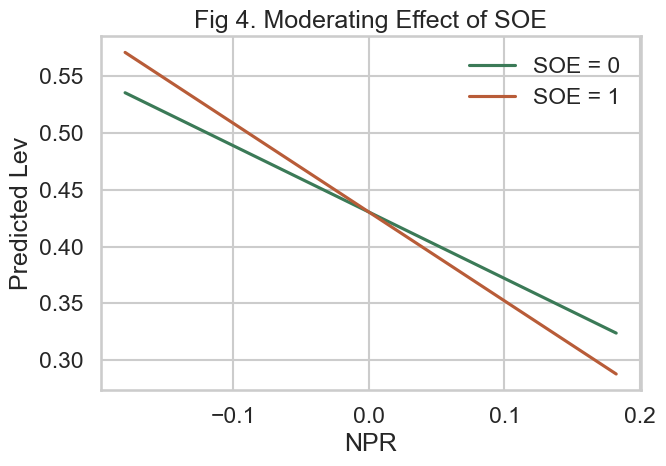

In [25]:
x_grid = np.linspace(analysis["npr"].quantile(0.01), analysis["npr"].quantile(0.99), 100)
means = analysis[["size", "tang", "growth", "ndts"]].mean()
intercept = m3.params["Intercept"]
private = intercept + m3.params["size"] * means["size"] + m3.params["tang"] * means["tang"] + m3.params["growth"] * means["growth"] + m3.params["ndts"] * means["ndts"] + m3.params["npr"] * x_grid
soe = intercept + m3.params["size"] * means["size"] + m3.params["tang"] * means["tang"] + m3.params["growth"] * means["growth"] + m3.params["ndts"] * means["ndts"] + (m3.params["npr"] + m3.params["npr_soe"]) * x_grid

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x_grid, private, label="SOE = 0", color="#3b7a57")
ax.plot(x_grid, soe, label="SOE = 1", color="#b85c38")
ax.set_xlabel("NPR")
ax.set_ylabel("Predicted Lev")
ax.set_title("Fig 4. Moderating Effect of SOE")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURES / "Fig4_soe_margins.png", dpi=300, bbox_inches="tight")
plt.show()


In [26]:
m4_df = analysis.copy()
for year in sorted(m4_df["year"].unique()):
    m4_df[f"npr_{year}"] = m4_df["npr"] * (m4_df["year"] == year)
terms = " + ".join([f"npr_{year}" for year in sorted(m4_df["year"].unique())])
m4 = fit_twfe(
    m4_df,
    f"lev ~ 0 + {terms} + size + tang + growth + ndts + EntityEffects + TimeEffects",
)

m4_yearly = pd.DataFrame({
    "year": sorted(m4_df["year"].unique()),
    "coef": [m4.params[f"npr_{year}"] for year in sorted(m4_df["year"].unique())],
    "se": [m4.std_errors[f"npr_{year}"] for year in sorted(m4_df["year"].unique())],
    "p_value": [m4.pvalues[f"npr_{year}"] for year in sorted(m4_df["year"].unique())],
})
m4_yearly["ci_low"] = m4_yearly["coef"] - 1.96 * m4_yearly["se"]
m4_yearly["ci_high"] = m4_yearly["coef"] + 1.96 * m4_yearly["se"]
m4_yearly


,year,coef,se,p_value,ci_low,ci_high
0,2010,-0.652195,0.064632,0.000000e+00,-0.778874,-0.525516
1,2011,-0.650623,0.058824,0.000000e+00,-0.765918,-0.535327
2,2012,-0.759086,0.053882,0.000000e+00,-0.864694,-0.653478
3,2013,-0.778002,0.053834,0.000000e+00,-0.883515,-0.672488
4,2014,-0.662503,0.053093,0.000000e+00,-0.766566,-0.558440
5,2015,-0.575319,0.048502,0.000000e+00,-0.670382,-0.480255
6,2016,-0.490188,0.062497,4.440892e-15,-0.612682,-0.367694
7,2017,-0.502565,0.086802,7.106443e-09,-0.672698,-0.332433
8,2018,-0.390289,0.054265,6.494805e-13,-0.496649,-0.283930
9,2019,-0.432820,0.055890,9.769963e-15,-0.542364,-0.323276


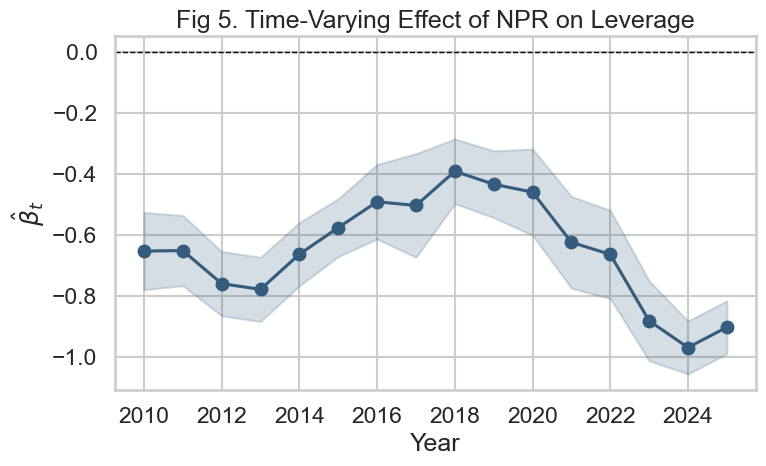

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(m4_yearly["year"], m4_yearly["coef"], marker="o", color="#355c7d")
ax.fill_between(m4_yearly["year"], m4_yearly["ci_low"], m4_yearly["ci_high"], color="#355c7d", alpha=0.2)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Year")
ax.set_ylabel(r"$\hat{\beta}_t$")
ax.set_title("Fig 5. Time-Varying Effect of NPR on Leverage")
fig.tight_layout()
fig.savefig(FIGURES / "Fig5_time_varying_beta.png", dpi=300, bbox_inches="tight")
plt.show()


In [28]:
display(Markdown(
    f'''
### 5.4 M4：时变系数模型

时变系数估计结果表明，`NPR` 对 `Lev` 的影响在 **2010-2025 年始终为负**，且全部年度系数均在统计上显著。这一发现说明，优序融资理论在样本期内并不是阶段性成立，而是具有较强的持续性。

尽管方向稳定，系数绝对值仍存在显著的时序波动。从结果看，负向效应在 **2012-2014 年** 较强，2015 年后有所减弱，并在 **2018 年** 左右达到相对低点（约为 **{m4_yearly.loc[m4_yearly['year']==2018, 'coef'].iloc[0]:.3f}**）。此后，负向关系再次增强，尤其在 **2023-2025 年** 达到样本期内最强水平，其中 2024 年系数约为 **{m4_yearly.loc[m4_yearly['year']==2024, 'coef'].iloc[0]:.3f}**。

这一演化路径说明，企业融资行为对盈利能力的响应并非固定不变，而会受到宏观政策环境、融资监管、信用扩张节奏与企业资产负债表调整需求的共同影响。从经济上看，样本后期负向关系显著增强，可能意味着企业在更严格的风险约束下更倾向于用内部现金流修复资产负债结构。

同时，这一结果也提醒我们：如果只报告一个样本期平均斜率，可能会掩盖企业融资行为在不同宏观阶段的显著差异。M4 的意义就在于展示这种动态异质性，使结论不仅停留在“方向是否为负”，还进一步扩展到“负向关系在何时更强、何时更弱”。'''
))



### 5.4 M4：时变系数模型

时变系数估计结果表明，`NPR` 对 `Lev` 的影响在 **2010-2025 年始终为负**，且全部年度系数均在统计上显著。这一发现说明，优序融资理论在样本期内并不是阶段性成立，而是具有较强的持续性。

尽管方向稳定，系数绝对值仍存在显著的时序波动。从结果看，负向效应在 **2012-2014 年** 较强，2015 年后有所减弱，并在 **2018 年** 左右达到相对低点（约为 **-0.390**）。此后，负向关系再次增强，尤其在 **2023-2025 年** 达到样本期内最强水平，其中 2024 年系数约为 **-0.969**。

这一演化路径说明，企业融资行为对盈利能力的响应并非固定不变，而会受到宏观政策环境、融资监管、信用扩张节奏与企业资产负债表调整需求的共同影响。从经济上看，样本后期负向关系显著增强，可能意味着企业在更严格的风险约束下更倾向于用内部现金流修复资产负债结构。

同时，这一结果也提醒我们：如果只报告一个样本期平均斜率，可能会掩盖企业融资行为在不同宏观阶段的显著差异。M4 的意义就在于展示这种动态异质性，使结论不仅停留在“方向是否为负”，还进一步扩展到“负向关系在何时更强、何时更弱”。

In [29]:
reg_table = save_regression_table(
    {
        "M1_TWFE": m1,
        "M1p_IFE": m1p,
        "M2_SOE": m2_soe,
        "M2_NonSOE": m2_non,
        "M3_Interaction": m3,
    },
    {
        "M1_TWFE": analysis["stkcd"].nunique(),
        "M1p_IFE": analysis["stkcd"].nunique(),
        "M2_SOE": analysis.loc[analysis["soe"] == 1, "stkcd"].nunique(),
        "M2_NonSOE": analysis.loc[analysis["soe"] == 0, "stkcd"].nunique(),
        "M3_Interaction": analysis["stkcd"].nunique(),
    },
)
reg_table.to_csv(TABLES / "Table4_regression_results.csv", index=False, encoding="utf-8-sig")
reg_table


,term,M1_TWFE,M1p_IFE,M2_SOE,M2_NonSOE,M3_Interaction
0,NPR,-0.6250***\n(0.0558),-0.4048***\n(0.0087),-0.8580***\n(0.0643),-0.5097***\n(0.0437),-0.5835***\n(0.0569)
1,NPR × SOE,—,—,—,—,-0.1972***\n(0.0532)
2,m2_growth,—,0.0019***\n(0.0002),—,—,—
3,Size,0.0788***\n(0.0044),0.0849***\n(0.0007),0.0746***\n(0.0069),0.0725***\n(0.0056),0.0792***\n(0.0044)
4,Tang,0.1085***\n(0.0179),0.1184***\n(0.0061),0.0569**\n(0.0282),0.1448***\n(0.0233),0.1077***\n(0.0177)
5,Growth,0.0238**\n(0.0099),0.0149***\n(0.0019),0.0225**\n(0.0097),0.0297***\n(0.0105),0.0235**\n(0.0098)
6,NDTS,0.0399\n(0.2042),-0.1539***\n(0.0566),-1.3173***\n(0.2586),0.5223**\n(0.2480),0.0854\n(0.2012)
7,公司FE,✓,✓,✓,✓,✓
8,年度FE,✓,交互FE,✓,✓,✓
9,聚类标准误,双向,Robust,双向,双向,双向


## 六、核心讨论问题


In [30]:
display(Markdown(
    f'''
### 6.1 理论检验：更支持权衡理论还是优序融资理论？

综合 M1-M3 的结果，本作业样本明显更支持**优序融资理论**。最核心的依据在于：无论是双向固定效应基准模型，还是产权分组回归与交互项模型，`NPR` 的系数始终显著为负。换言之，在中国 A 股上市公司中，盈利能力越强的企业并没有表现出更高的债务依赖，反而更可能降低杠杆率。

如果站在权衡理论的视角，盈利能力提高应增强债务税盾利用能力并提升债务承受能力，因此理论上应出现正向关系；但样本并未支持这一方向。相反，实证结果更符合“内部融资优先”的逻辑：当企业拥有更充足的内部留存收益时，其对外部债务的依赖下降，杠杆率因而回落。

### 6.2 产权性质是否改变这一结论？

答案是肯定的。M2 与 M3 共同表明，SOE 与非 SOE 的 `NPR-Lev` 关系在统计上存在显著差异。值得注意的是，负向关系更强的并不是非国有企业，而是国有企业。该结果提示，在中国制度环境下，产权异质性的影响并不只体现为融资约束程度不同，也可能体现为债务调整目标、政策约束和杠杆考核机制的差异。

### 6.3 时序稳定性如何？

M4 的结果显示，`NPR` 对 `Lev` 的负向效应在 2010-2025 年间始终存在，但强度具有明显阶段性。2015-2020 年期间系数绝对值相对收敛，而 2021 年以后又重新扩大。这意味着宏观政策、信用环境和企业去杠杆压力会影响这一关系的强弱，但不会改变其基本方向。

### 6.4 IFE 与 TWFE 比较说明了什么？

M1' 中 `NPR` 的系数绝对值小于 M1，但依然显著为负。这表明，TWFE 中的部分负向关系确实可能吸收了共同的时变冲击；然而即便在进一步控制这类不可观测冲击后，核心结论依然稳健。因此，从稳健性角度看，本作业关于优序融资理论的结论是可信的。'''
))



### 6.1 理论检验：更支持权衡理论还是优序融资理论？

综合 M1-M3 的结果，本作业样本明显更支持**优序融资理论**。最核心的依据在于：无论是双向固定效应基准模型，还是产权分组回归与交互项模型，`NPR` 的系数始终显著为负。换言之，在中国 A 股上市公司中，盈利能力越强的企业并没有表现出更高的债务依赖，反而更可能降低杠杆率。

如果站在权衡理论的视角，盈利能力提高应增强债务税盾利用能力并提升债务承受能力，因此理论上应出现正向关系；但样本并未支持这一方向。相反，实证结果更符合“内部融资优先”的逻辑：当企业拥有更充足的内部留存收益时，其对外部债务的依赖下降，杠杆率因而回落。

### 6.2 产权性质是否改变这一结论？

答案是肯定的。M2 与 M3 共同表明，SOE 与非 SOE 的 `NPR-Lev` 关系在统计上存在显著差异。值得注意的是，负向关系更强的并不是非国有企业，而是国有企业。该结果提示，在中国制度环境下，产权异质性的影响并不只体现为融资约束程度不同，也可能体现为债务调整目标、政策约束和杠杆考核机制的差异。

### 6.3 时序稳定性如何？

M4 的结果显示，`NPR` 对 `Lev` 的负向效应在 2010-2025 年间始终存在，但强度具有明显阶段性。2015-2020 年期间系数绝对值相对收敛，而 2021 年以后又重新扩大。这意味着宏观政策、信用环境和企业去杠杆压力会影响这一关系的强弱，但不会改变其基本方向。

### 6.4 IFE 与 TWFE 比较说明了什么？

M1' 中 `NPR` 的系数绝对值小于 M1，但依然显著为负。这表明，TWFE 中的部分负向关系确实可能吸收了共同的时变冲击；然而即便在进一步控制这类不可观测冲击后，核心结论依然稳健。因此，从稳健性角度看，本作业关于优序融资理论的结论是可信的。

## 八、结论


In [31]:
display(Markdown(
    f'''
综合本作业的样本筛选、描述性统计与多种面板模型结果，可以得到以下结论。

第一，A 股上市公司中盈利能力与杠杆率之间存在稳健的显著负相关关系。无论采用双向固定效应基准模型，还是考虑时变共同冲击的交互固定效应近似模型，`NPR` 的系数始终显著为负，因此总体上更支持优序融资理论。

第二，产权性质会显著调节这一关系。SOE 与非 SOE 的 `NPR-Lev` 斜率不仅都为负，而且国有企业的负向关系更强。这表明在中国特定制度背景下，资本结构选择不仅受融资约束与信息不对称影响，也受到政策约束、历史杠杆水平与资产负债表修复需求的共同作用。

第三，盈利能力对杠杆率的影响并非在全时期完全恒定。时变系数模型揭示，样本期内该负向关系始终存在，但强度在不同年份间存在明显波动。由此可见，资本结构调整行为既有稳定的融资顺序逻辑，也会受到宏观环境变化的动态影响。

第四，从方法论角度看，作业结果表明：如果仅依赖简单相关关系或单一模型，容易低估中国上市公司资本结构行为的复杂性。通过样本筛选、异常值处理、产权分组与时变系数分析的逐层推进，能够更完整地揭示盈利能力与杠杆率之间的经验规律。

总体而言，本作业的证据支持这样一个判断：在 2010-2025 年的中国 A 股上市公司样本中，企业资本结构行为整体更符合优序融资理论；这一规律在产权维度和时间维度上都表现出重要异质性。'''
))



综合本作业的样本筛选、描述性统计与多种面板模型结果，可以得到以下结论。

第一，A 股上市公司中盈利能力与杠杆率之间存在稳健的显著负相关关系。无论采用双向固定效应基准模型，还是考虑时变共同冲击的交互固定效应近似模型，`NPR` 的系数始终显著为负，因此总体上更支持优序融资理论。

第二，产权性质会显著调节这一关系。SOE 与非 SOE 的 `NPR-Lev` 斜率不仅都为负，而且国有企业的负向关系更强。这表明在中国特定制度背景下，资本结构选择不仅受融资约束与信息不对称影响，也受到政策约束、历史杠杆水平与资产负债表修复需求的共同作用。

第三，盈利能力对杠杆率的影响并非在全时期完全恒定。时变系数模型揭示，样本期内该负向关系始终存在，但强度在不同年份间存在明显波动。由此可见，资本结构调整行为既有稳定的融资顺序逻辑，也会受到宏观环境变化的动态影响。

第四，从方法论角度看，作业结果表明：如果仅依赖简单相关关系或单一模型，容易低估中国上市公司资本结构行为的复杂性。通过样本筛选、异常值处理、产权分组与时变系数分析的逐层推进，能够更完整地揭示盈利能力与杠杆率之间的经验规律。

总体而言，本作业的证据支持这样一个判断：在 2010-2025 年的中国 A 股上市公司样本中，企业资本结构行为整体更符合优序融资理论；这一规律在产权维度和时间维度上都表现出重要异质性。

## 九、导出作业结果


In [32]:
sample_selection.to_csv(TABLES / "Table1_sample_selection.csv", index=False, encoding="utf-8-sig")
desc_stats.to_csv(TABLES / "Table2_descriptive_statistics.csv", index=False, encoding="utf-8-sig")
corr_pretty.to_csv(TABLES / "Table3_correlation_matrix.csv", encoding="utf-8-sig")
m4_yearly.to_csv(TABLES / "Table5_time_varying_coefficients.csv", index=False, encoding="utf-8-sig")

results_summary = {
    "sample_selection": sample_selection.to_dict(orient="records"),
    "m1_npr": float(m1.params["npr"]),
    "m1p_npr": float(m1p.params["npr"]),
    "m2_soe_npr": float(m2_soe.params["npr"]),
    "m2_nonsoe_npr": float(m2_non.params["npr"]),
    "m3_npr_soe": float(m3.params["npr_soe"]),
}
(OUTPUT / "results_summary.json").write_text(json.dumps(results_summary, ensure_ascii=False, indent=2), encoding="utf-8")

print("Saved tables to:", TABLES)
print("Saved figures to:", FIGURES)


Saved tables to: [项目根目录]/output/tables
Saved figures to: [项目根目录]/output/figures
